In [1]:
!pip install mindcv

Looking in indexes: http://repo.myhuaweicloud.com/repository/pypi/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.2/275.2 kB 28.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import numpy as np
import mindspore as ms
import mindspore.nn as nn
import mindspore.dataset as ds
import mindspore.dataset.transforms as transforms
import mindspore.dataset.vision as vision
from mindspore import Tensor
from mindspore.train import Model, ModelCheckpoint, CheckpointConfig, LossMonitor, TimeMonitor
import mindcv
import moxing as mox

# ============================================================
# MindSpore Context Setup (Ascend NPU)
# ============================================================
# GRAPH_MODE is required for dataset_sink_mode=True on Ascend
ms.set_context(mode=ms.PYNATIVE_MODE, device_target="Ascend", device_id=0)
print(f"[INFO] MindSpore version: {ms.__version__}")

# ============================================================
# Configuration
# ============================================================
BATCH_SIZE    = 32
NUM_CLASSES   = 14
LEARNING_RATE = 0.001
NUM_EPOCHS    = 20

OBS_DATA_PATH   = 'obs://dermalens/dermalens_dataset'
LOCAL_DATA_PATH = '/home/ma-user/work/dermalens_data_v1'
CKPT_SAVE_DIR   = '/home/ma-user/work/checkpoints'

if not os.path.exists(LOCAL_DATA_PATH):
    print("[INFO] Copying dataset from OBS...")
    mox.file.copy_parallel(OBS_DATA_PATH, LOCAL_DATA_PATH)
    print("[INFO] Dataset ready.")

os.makedirs(CKPT_SAVE_DIR, exist_ok=True)

# ============================================================
# 1. Data Pipeline
# ============================================================
# MindSpore vision.Normalize expects mean/std scaled to [0, 255]
# when the input image is uint8 after Decode()
mean = [0.485 * 255, 0.456 * 255, 0.406 * 255]
std  = [0.229 * 255, 0.224 * 255, 0.225 * 255]

def create_dataset(data_path, split, batch_size, shuffle=False):
    dataset = ds.ImageFolderDataset(
        os.path.join(data_path, split),
        num_parallel_workers=4,
        shuffle=shuffle
    )

    if split == 'train':
        transform_list = [
            vision.Decode(),
            vision.Resize((224, 224)),
            vision.RandomHorizontalFlip(),
            vision.RandomRotation(15),
            vision.Normalize(mean=mean, std=std),
            vision.HWC2CHW(),                       # convert HWC uint8 -> CHW float32
        ]
    else:
        transform_list = [
            vision.Decode(),
            vision.Resize((224, 224)),
            vision.Normalize(mean=mean, std=std),
            vision.HWC2CHW(),
        ]

    dataset = dataset.map(operations=transform_list, input_columns=["image"])
    # Labels must be int32 for SoftmaxCrossEntropyWithLogits(sparse=True)
    dataset = dataset.map(
        operations=transforms.TypeCast(ms.int32),
        input_columns=["label"]
    )
    dataset = dataset.batch(batch_size, drop_remainder=(split == 'train'))
    return dataset

train_dataset = create_dataset(LOCAL_DATA_PATH, 'train', BATCH_SIZE, shuffle=True)
valid_dataset = create_dataset(LOCAL_DATA_PATH, 'valid', BATCH_SIZE)
test_dataset  = create_dataset(LOCAL_DATA_PATH, 'test',  BATCH_SIZE)

steps_per_epoch = train_dataset.get_dataset_size()
print(f"[INFO] Train steps per epoch: {steps_per_epoch}")

# ============================================================
# 2. Ensemble Architecture
# ============================================================
class ResNetMobileNetEnsemble(nn.Cell):
    def __init__(self, num_classes):
        super(ResNetMobileNetEnsemble, self).__init__()

        # --- ResNet50 backbone ---
        # mindcv does not support num_classes=0; build with 1000 then strip the head
        resnet = mindcv.create_model("resnet50", pretrained=True, num_classes=1000)
        resnet.classifier = nn.Identity()           # strips FC head -> [B, 2048]
        self.resnet = resnet

        # --- MobileNetV3-Large backbone ---
        # Correct mindcv registry name is "mobilenet_v2_100" (includes width suffix)
        # "mobilenet_v3_large" does NOT exist and raises RuntimeError: Unknown model
        mobilenet = mindcv.create_model("mobilenet_v2_100", pretrained=True, num_classes=1000)
        # Tap features + pool directly, bypassing the Dense classifier layers
        # mobilenet.features -> [B, 960, 7, 7], mobilenet.pool -> [B, 960]
        self.mobilenet_features = mobilenet.features
        self.mobilenet_pool     = mobilenet.pool

        # --- Fusion classifier ---
        # ResNet: 2048  +  MobileNet pool output: 1280  =  3328
        self.classifier = nn.SequentialCell([
            nn.Dense(2048 + 1280, 512),
            nn.ReLU(),
            # Per r2.0 docs: nn.Dropout(p=...) where p is the DROP rate.
            # keep_prob is deprecated in r2.0 — use p= instead.
            nn.Dropout(p=0.3),
            nn.Dense(512, num_classes),
        ])

        self.concat  = ms.ops.Concat(axis=1)
        self.flatten = nn.Flatten()

    def construct(self, x):
        x1 = self.resnet(x)                 # [B, 2048]

        x2 = self.mobilenet_features(x)     # [B, 960, 7, 7]
        x2 = self.mobilenet_pool(x2)        # [B, 960] or [B, 960, 1, 1]
        x2 = self.flatten(x2)               # [B, 960]

        x_cat = self.concat((x1, x2))       # [B, 3008]
        out   = self.classifier(x_cat)      # [B, num_classes]
        return out

# ============================================================
# 3. Loss, Optimizer, LR Schedule
# ============================================================
network = ResNetMobileNetEnsemble(NUM_CLASSES)

# SoftmaxCrossEntropyWithLogits: sparse=True accepts integer labels directly
loss_fn = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction='mean')

# Piecewise LR: len(milestone) MUST equal len(learning_rates) — per docs
total_steps = NUM_EPOCHS * steps_per_epoch
lr_schedule = nn.piecewise_constant_lr(
    milestone=[
        7  * steps_per_epoch,    # end of epoch 7
        14 * steps_per_epoch,    # end of epoch 14
        total_steps,             # end of training  <- 3rd milestone required
    ],
    learning_rates=[
        LEARNING_RATE,           # epochs 1-7
        LEARNING_RATE * 0.1,     # epochs 8-14
        LEARNING_RATE * 0.01,    # epochs 15-20
    ]
)

optimizer = nn.Adam(network.trainable_params(), learning_rate=lr_schedule)

# ============================================================
# 4. Mixed Precision
# ============================================================
# O1 (selective FP16 via AST rewrite) is BROKEN in Jupyter notebooks:
# both Model(amp_level="O1") and ms.amp.auto_mixed_precision(..., "O1")
# internally call ms.rewrite.SymbolTree.create() -> inspect.getsource(),
# which raises OSError because the class is defined in __main__ with no
# backing .py file on disk.
#
# O2 uses network.to_float(float16) + keeps BatchNorm in FP32 + dynamic
# loss scale. This path has NO inspect.getsource dependency and works
# correctly in notebooks. It is also the recommended level for GPU, and
# gives equivalent training stability to O1 for this architecture.
#
# Pass amp_level directly to Model() so loss scale is wired up correctly
# per the docs: "need to set parameter optimizer at the same time".

model = Model(
    network,
    loss_fn=loss_fn,
    optimizer=optimizer,
    metrics={"accuracy"},
    amp_level="O0",       # O0: no mixed precision, avoids OOM from FP16 activation overhead
)

# ============================================================
# 5. Callbacks
# ============================================================
ckpt_config = CheckpointConfig(
    save_checkpoint_steps=steps_per_epoch,  # save once per epoch
    keep_checkpoint_max=5
)
ckpt_callback = ModelCheckpoint(
    prefix="dermalens_ensemble",
    directory=CKPT_SAVE_DIR,
    config=ckpt_config
)

# LossMonitor: per_print_times=steps_per_epoch prints loss once per epoch
loss_monitor = LossMonitor(per_print_times=steps_per_epoch)
time_monitor = TimeMonitor()

# ============================================================
# 6. Train with Model.fit()
# ============================================================
# fit() signature per r2.0 docs:
#   fit(epoch, train_dataset, valid_dataset=None, valid_frequency=1,
#       callbacks=None, dataset_sink_mode=False, valid_dataset_sink_mode=False, ...)
# dataset_sink_mode=True uses Ascend's fast DMA path (Ascend equivalent of pin_memory).

print("[INFO] Starting training...")
model.fit(
    NUM_EPOCHS,
    train_dataset,
    valid_dataset,
    callbacks=[ckpt_callback, loss_monitor, time_monitor],
    dataset_sink_mode=False,
    valid_dataset_sink_mode=False,
)

# ============================================================
# 7. Evaluate on Test Set
# ============================================================
print("\n[INFO] Evaluating on test set...")
test_metrics = model.eval(test_dataset, dataset_sink_mode=True)
print(f"[INFO] Test metrics: {test_metrics}")

# ============================================================
# 8. Export to ONNX
# ============================================================
# Load the latest checkpoint back into the raw network before exporting
ckpt_files = sorted(
    [f for f in os.listdir(CKPT_SAVE_DIR) if f.endswith('.ckpt')],
    key=lambda f: os.path.getmtime(os.path.join(CKPT_SAVE_DIR, f))
)
if ckpt_files:
    best_ckpt = os.path.join(CKPT_SAVE_DIR, ckpt_files[-1])
    print(f"[INFO] Loading checkpoint: {best_ckpt}")
    ms.load_checkpoint(best_ckpt, net=network)

# set_train(False) = eval mode: disables Dropout, sets BatchNorm to inference mode
network.set_train(False)

dummy_input = Tensor(np.random.randn(1, 3, 224, 224).astype(np.float32))

# MindSpore's ONNX exporter does not support HSwish (used in MobileNetV3).
# Export as MindIR first, then convert to ONNX on PC using mind_converter.
mindir_path = '/home/ma-user/work/dermalens_ensemble'
ms.export(network, dummy_input, file_name=mindir_path, file_format='MINDIR')
print(f"[INFO] MindIR model exported -> {mindir_path}.mindir")
print("[INFO] Next step: convert MindIR to ONNX on your PC using:")
print("       converter_lite --fmk=MINDIR --modelFile=dermalens_ensemble.mindir --outputFile=dermalens_ensemble --saveType=ONNX")

[WARNING] ME(3499:281473597735088,MainProcess):2026-04-20-23:13:19.896.124 [mindspore/run_check/_check_version.py:407] Can not find the tbe operator implementation(need by mindspore-ascend). Please check whether the Environment Variable PYTHONPATH is set. For details, refer to the installation guidelines: https://www.mindspore.cn/install
/home/ma-user/anaconda3/envs/MindSpore/lib/python3.10/site-packages/numpy/core/getlimits.py:499: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/ma-user/anaconda3/envs/MindSpore/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/home/ma-user/anaconda3/envs/MindSpore/lib/python3.10/site-packages/numpy/core/getlimits.py:499: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type 

[INFO] MindSpore version: 2.4.10
[INFO] Copying dataset from OBS...


INFO:root:Listing OBS: 1000
INFO:root:Listing OBS: 2000
INFO:root:Listing OBS: 3000
INFO:root:Listing OBS: 4000
INFO:root:Listing OBS: 5000
INFO:root:Listing OBS: 6000
INFO:root:Listing OBS: 7000
INFO:root:Listing OBS: 8000
INFO:root:Listing OBS: 9000
INFO:root:List OBS time cost: 1.37 seconds.
INFO:root:1000/9546
INFO:root:2000/9546
INFO:root:3000/9546
INFO:root:4000/9546
INFO:root:5000/9546
INFO:root:6000/9546
INFO:root:7000/9546
INFO:root:8000/9546
INFO:root:9000/9546
INFO:root:Copy parallel total time cost: 15.46 seconds.
[WARNING] CORE(3499,ffffadce80b0,python):2026-04-20-23:13:46.937.376 [mindspore/core/utils/ms_context.cc:530] GetJitLevel] Set jit level to O2 for rank table startup method.


[INFO] Dataset ready.
[INFO] Train steps per epoch: 232


INFO:mindcv.utils.download:Downloading from https://download.mindspore.cn/toolkits/mindcv/resnet/resnet50-e0733ab8.ckpt to /home/ma-user/.mindspore/models/resnet50-e0733ab8.ckpt ...
104855552B [00:03, 30713225.10B/s]                                
INFO:mindcv.utils.download:Downloading from https://download.mindspore.cn/toolkits/mindcv/mobilenet/mobilenetv2/mobilenet_v2_100-d5532038.ckpt to /home/ma-user/.mindspore/models/mobilenet_v2_100-d5532038.ckpt ...
28998656B [00:00, 46010520.44B/s]                               


[INFO] Starting training...
....................epoch: 1 step: 232, loss is 2.092949390411377
.Eval epoch time: 4947.483 ms, per step time: 164.916 ms
Eval result: epoch 1, metrics: {'accuracy': 0.5755627009646302}
Train epoch time: 4958.943 ms, per step time: 21.375 ms
epoch: 2 step: 232, loss is 0.9413923025131226
Eval epoch time: 3084.886 ms, per step time: 102.830 ms
Eval result: epoch 2, metrics: {'accuracy': 0.6720257234726688}
Train epoch time: 3096.471 ms, per step time: 13.347 ms
epoch: 3 step: 232, loss is 0.8050730228424072
Eval epoch time: 3098.340 ms, per step time: 103.278 ms
Eval result: epoch 3, metrics: {'accuracy': 0.6720257234726688}
Train epoch time: 3108.444 ms, per step time: 13.398 ms
epoch: 4 step: 232, loss is 0.7881134748458862
Eval epoch time: 2931.674 ms, per step time: 97.722 ms
Eval result: epoch 4, metrics: {'accuracy': 0.6666666666666666}
Train epoch time: 2942.061 ms, per step time: 12.681 ms
epoch: 5 step: 232, loss is 0.5487531423568726
Eval epoch tim

In [4]:
import numpy as np
import mindspore as ms
import mindspore.nn as nn
from mindspore import Tensor
import mindcv
import moxing as mox

# ============================================================
# IMPORTANT: Use PYNATIVE first to load checkpoint,
# then switch to GRAPH_MODE for export — same pattern
# as the successful 2-epoch test
# ============================================================
ms.set_context(mode=ms.PYNATIVE_MODE, device_target="Ascend", device_id=0)

NUM_CLASSES = 14
CKPT_PATH   = '/home/ma-user/work/checkpoints/dermalens_ensemble-20_232.ckpt'  # update if different
ONNX_PATH   = '/home/ma-user/work/dermalens_ensemble'

# ============================================================
# Exact same architecture as training
# ============================================================
class ResNetMobileNetEnsemble(nn.Cell):
    def __init__(self, num_classes):
        super(ResNetMobileNetEnsemble, self).__init__()

        resnet = mindcv.create_model("resnet50", pretrained=False, num_classes=1000)
        resnet.classifier = nn.Identity()
        self.resnet = resnet

        mobilenet = mindcv.create_model("mobilenet_v2_100", pretrained=False, num_classes=1000)
        self.mobilenet_features = mobilenet.features
        self.mobilenet_pool     = mobilenet.pool

        self.classifier = nn.SequentialCell([
            nn.Dense(2048 + 1280, 512),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Dense(512, num_classes),
        ])

        self.concat  = ms.ops.Concat(axis=1)
        self.flatten = nn.Flatten()

    def construct(self, x):
        x1 = self.resnet(x)
        x2 = self.mobilenet_features(x)
        x2 = self.mobilenet_pool(x2)
        x2 = self.flatten(x2)
        x_cat = self.concat((x1, x2))
        return self.classifier(x_cat)

# ============================================================
# Load checkpoint
# ============================================================
print("[INFO] Building network...")
network = ResNetMobileNetEnsemble(NUM_CLASSES)

print(f"[INFO] Loading checkpoint: {CKPT_PATH}")
ms.load_checkpoint(CKPT_PATH, net=network)
network.set_train(False)
print("[INFO] Checkpoint loaded.")

# ============================================================
# Switch to GRAPH_MODE for export — same as 2-epoch test
# ============================================================
ms.set_context(mode=ms.GRAPH_MODE, device_target="Ascend", device_id=0)

# ============================================================
# Export ONNX
# ============================================================
print("[INFO] Exporting to ONNX...")
dummy_input = Tensor(np.random.randn(1, 3, 224, 224).astype(np.float32))
ms.export(network, dummy_input, file_name=ONNX_PATH, file_format='ONNX')
print(f"[INFO] Done -> {ONNX_PATH}.onnx")

# ============================================================
# Copy to OBS
# ============================================================
print("[INFO] Copying to OBS...")
mox.file.copy(
    f'{ONNX_PATH}.onnx',
    'obs://dermalens/exports/dermalens_ensemble.onnx'
)
print("[INFO] Saved to OBS: obs://dermalens/exports/dermalens_ensemble.onnx")
print("[INFO] Next step: run convert_to_rknn.py on your x86 PC")

[WARNING] ME(3499:281473597735088,MainProcess):2026-04-20-23:44:52.857.684 [mindspore/run_check/_check_version.py:407] Can not find the tbe operator implementation(need by mindspore-ascend). Please check whether the Environment Variable PYTHONPATH is set. For details, refer to the installation guidelines: https://www.mindspore.cn/install
[WARNING] ME(3499:281473597735088,MainProcess):2026-04-20-23:44:52.859.140 [mindspore/context.py:1270] For 'context.set_context' in Ascend backend, the backend is already initialized, please set it before the definition of any Tensor and Parameter, and the instantiation and execution of any operation and net, otherwise the settings may not take effect. 
[WARNING] ME(3499:281473597735088,MainProcess):2026-04-20-23:44:52.861.803 [mindspore/run_check/_check_version.py:407] Can not find the tbe operator implementation(need by mindspore-ascend). Please check whether the Environment Variable PYTHONPATH is set. For details, refer to the installation guideline

[INFO] Building network...
[INFO] Loading checkpoint: /home/ma-user/work/checkpoints/dermalens_ensemble-20_232.ckpt


[WARNING] ME(3499:281473597735088,MainProcess):2026-04-20-23:44:58.360.384 [mindspore/run_check/_check_version.py:407] Can not find the tbe operator implementation(need by mindspore-ascend). Please check whether the Environment Variable PYTHONPATH is set. For details, refer to the installation guidelines: https://www.mindspore.cn/install
[WARNING] ME(3499:281473597735088,MainProcess):2026-04-20-23:44:58.361.364 [mindspore/context.py:1270] For 'context.set_context' in Ascend backend, the backend is already initialized, please set it before the definition of any Tensor and Parameter, and the instantiation and execution of any operation and net, otherwise the settings may not take effect. 
[WARNING] ME(3499:281473597735088,MainProcess):2026-04-20-23:44:58.363.831 [mindspore/run_check/_check_version.py:407] Can not find the tbe operator implementation(need by mindspore-ascend). Please check whether the Environment Variable PYTHONPATH is set. For details, refer to the installation guideline

[INFO] Checkpoint loaded.
[INFO] Exporting to ONNX...
[INFO] Done -> /home/ma-user/work/dermalens_ensemble.onnx
[INFO] Copying to OBS...
[INFO] Saved to OBS: obs://dermalens/exports/dermalens_ensemble.onnx
[INFO] Next step: run convert_to_rknn.py on your x86 PC


In [6]:
!pip install seaborn

Looking in indexes: http://repo.myhuaweicloud.com/repository/pypi/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 11.4 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


INFO:numexpr.utils:Note: detected 192 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
INFO:numexpr.utils:Note: NumExpr detected 192 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:NumExpr defaulting to 8 threads.
[WARNING] ME(3499:281473597735088,MainProcess):2026-04-20-23:49:07.519.853 [mindspore/run_check/_check_version.py:407] Can not find the tbe operator implementation(need by mindspore-ascend). Please check whether the Environment Variable PYTHONPATH is set. For details, refer to the installation guidelines: https://www.mindspore.cn/install
[WARNING] ME(3499:281473597735088,MainProcess):2026-04-20-23:49:07.520.961 [mindspore/context.py:1270] For 'context.set_context' in Ascend backend, the backend is already initialized, please set it before the definition of any Tensor and Parameter, and the instantiation and execution of any operation and net, otherwise the settings may not take effect. 

[INFO] Classes: ['Basal Cell Carcinoma', 'Dermatofibroma', 'Eczema', 'Healthy Skin', 'Herpes', 'Impetigo', 'Keratosis', 'Leprosy', 'Melanocytic Nevi', 'Melanoma', 'Psoriasis', 'Scabies', 'Tinea', 'Warts']
[INFO] Loading checkpoint...
[INFO] Checkpoint loaded.
[INFO] Running inference on test set...
.[INFO] Total test samples: 1165

  Top-1 Accuracy : 81.29%
  Top-3 Accuracy : 97.42%
  Top-5 Accuracy : 99.91%

[INFO] Per-class metrics:
                      precision    recall  f1-score   support

Basal Cell Carcinoma     0.8627    0.8381    0.8502       105
      Dermatofibroma     0.7083    0.5312    0.6071        32
              Eczema     0.6786    0.5644    0.6162       101
        Healthy Skin     0.8857    0.9118    0.8986        34
              Herpes     0.8571    0.8000    0.8276        75
            Impetigo     0.8545    0.8393    0.8468        56
           Keratosis     0.9293    0.9200    0.9246       100
             Leprosy     0.9892    1.0000    0.9946        92
  

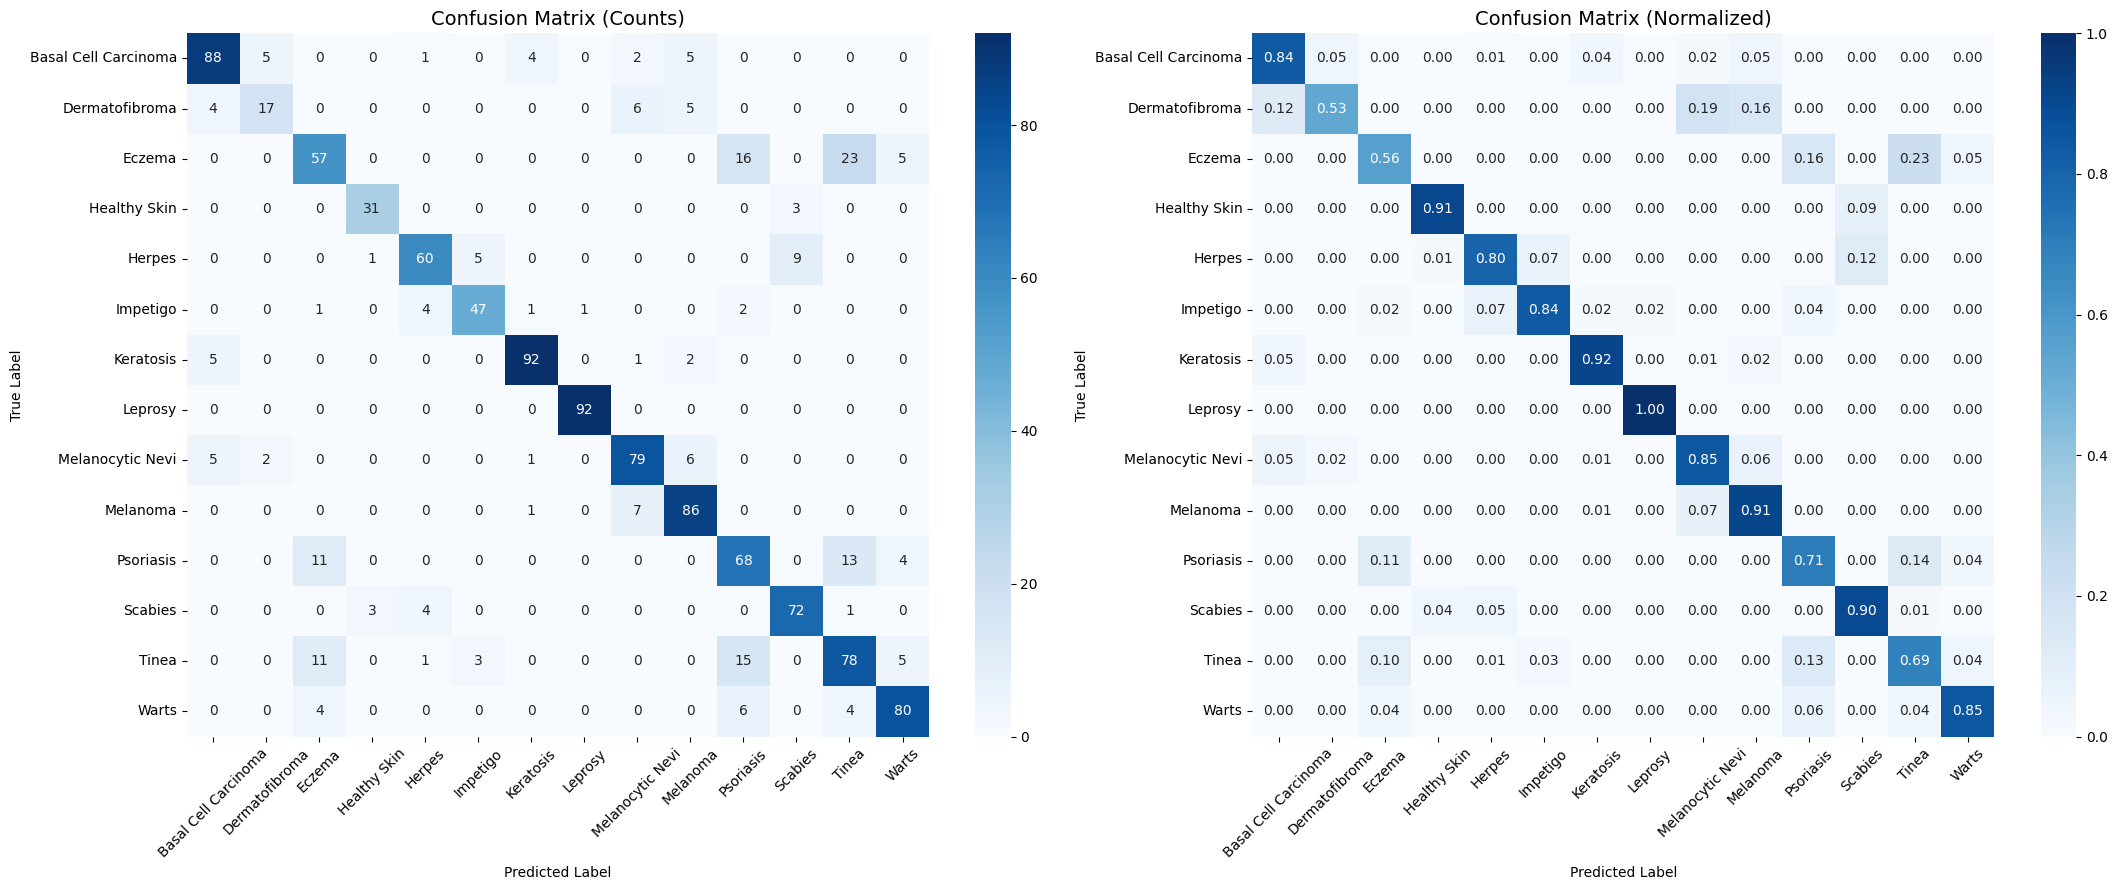

[INFO] Confusion matrix saved -> /home/ma-user/work/confusion_matrix.png


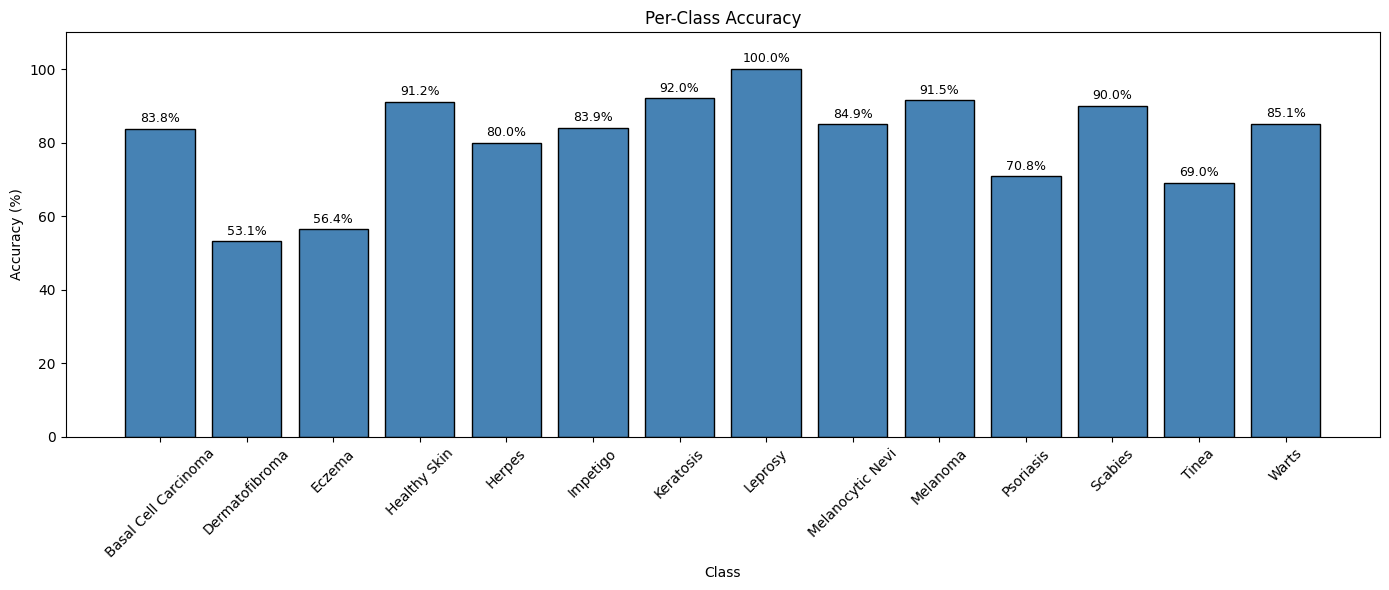

[INFO] Per-class accuracy saved -> /home/ma-user/work/per_class_accuracy.png


In [7]:
import os
import numpy as np
import mindspore as ms
import mindspore.nn as nn
import mindspore.dataset as ds
import mindspore.dataset.transforms as transforms
import mindspore.dataset.vision as vision
from mindspore import Tensor
import mindcv
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, top_k_accuracy_score)

ms.set_context(mode=ms.PYNATIVE_MODE, device_target="Ascend", device_id=0)

NUM_CLASSES     = 14
LOCAL_DATA_PATH = '/home/ma-user/work/dermalens_data_v1'
CKPT_PATH       = '/home/ma-user/work/checkpoints/dermalens_ensemble-20_232.ckpt'  # update if needed
BATCH_SIZE      = 32

# ============================================================
# Dataset
# ============================================================
mean = [0.485 * 255, 0.456 * 255, 0.406 * 255]
std  = [0.229 * 255, 0.224 * 255, 0.225 * 255]

test_dataset = ds.ImageFolderDataset(
    os.path.join(LOCAL_DATA_PATH, 'test'),
    num_parallel_workers=4,
    shuffle=False
)
transform_list = [
    vision.Decode(),
    vision.Resize((224, 224)),
    vision.Normalize(mean=mean, std=std),
    vision.HWC2CHW(),
]
test_dataset = test_dataset.map(operations=transform_list, input_columns=["image"])
test_dataset = test_dataset.map(operations=transforms.TypeCast(ms.int32), input_columns=["label"])
test_dataset = test_dataset.batch(BATCH_SIZE)

# Get class names from folder structure
class_names = sorted(os.listdir(os.path.join(LOCAL_DATA_PATH, 'test')))
print(f"[INFO] Classes: {class_names}")

# ============================================================
# Model
# ============================================================
class ResNetMobileNetEnsemble(nn.Cell):
    def __init__(self, num_classes):
        super(ResNetMobileNetEnsemble, self).__init__()
        resnet = mindcv.create_model("resnet50", pretrained=False, num_classes=1000)
        resnet.classifier = nn.Identity()
        self.resnet = resnet
        mobilenet = mindcv.create_model("mobilenet_v2_100", pretrained=False, num_classes=1000)
        self.mobilenet_features = mobilenet.features
        self.mobilenet_pool     = mobilenet.pool
        self.classifier = nn.SequentialCell([
            nn.Dense(2048 + 1280, 512),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Dense(512, num_classes),
        ])
        self.concat  = ms.ops.Concat(axis=1)
        self.flatten = nn.Flatten()

    def construct(self, x):
        x1 = self.resnet(x)
        x2 = self.mobilenet_features(x)
        x2 = self.mobilenet_pool(x2)
        x2 = self.flatten(x2)
        return self.classifier(self.concat((x1, x2)))

# ============================================================
# Load checkpoint
# ============================================================
print("[INFO] Loading checkpoint...")
network = ResNetMobileNetEnsemble(NUM_CLASSES)
ms.load_checkpoint(CKPT_PATH, net=network)
network.set_train(False)
print("[INFO] Checkpoint loaded.")

# ============================================================
# Run inference
# ============================================================
print("[INFO] Running inference on test set...")
all_preds  = []
all_labels = []
all_probs  = []

softmax = nn.Softmax(axis=1)

for batch in test_dataset.create_tuple_iterator():
    images, labels = batch
    logits = network(images)
    probs  = softmax(logits)
    preds  = logits.argmax(axis=1)

    all_preds.extend(preds.asnumpy().tolist())
    all_labels.extend(labels.asnumpy().tolist())
    all_probs.extend(probs.asnumpy().tolist())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print(f"[INFO] Total test samples: {len(all_labels)}")

# ============================================================
# 1. Overall Accuracy
# ============================================================
acc = accuracy_score(all_labels, all_preds)
top3_acc = top_k_accuracy_score(all_labels, all_probs, k=3)
top5_acc = top_k_accuracy_score(all_labels, all_probs, k=5)

print(f"\n{'='*50}")
print(f"  Top-1 Accuracy : {acc*100:.2f}%")
print(f"  Top-3 Accuracy : {top3_acc*100:.2f}%")
print(f"  Top-5 Accuracy : {top5_acc*100:.2f}%")
print(f"{'='*50}\n")

# ============================================================
# 2. Classification Report (precision, recall, F1 per class)
# ============================================================
print("[INFO] Per-class metrics:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# ============================================================
# 3. Confusion Matrix
# ============================================================
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=45)

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/home/ma-user/work/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("[INFO] Confusion matrix saved -> /home/ma-user/work/confusion_matrix.png")

# ============================================================
# 4. Per-class accuracy bar chart
# ============================================================
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(class_names, per_class_acc * 100, color='steelblue', edgecolor='black')
ax.set_xlabel('Class')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy')
ax.set_ylim(0, 110)
ax.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/home/ma-user/work/per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("[INFO] Per-class accuracy saved -> /home/ma-user/work/per_class_accuracy.png")